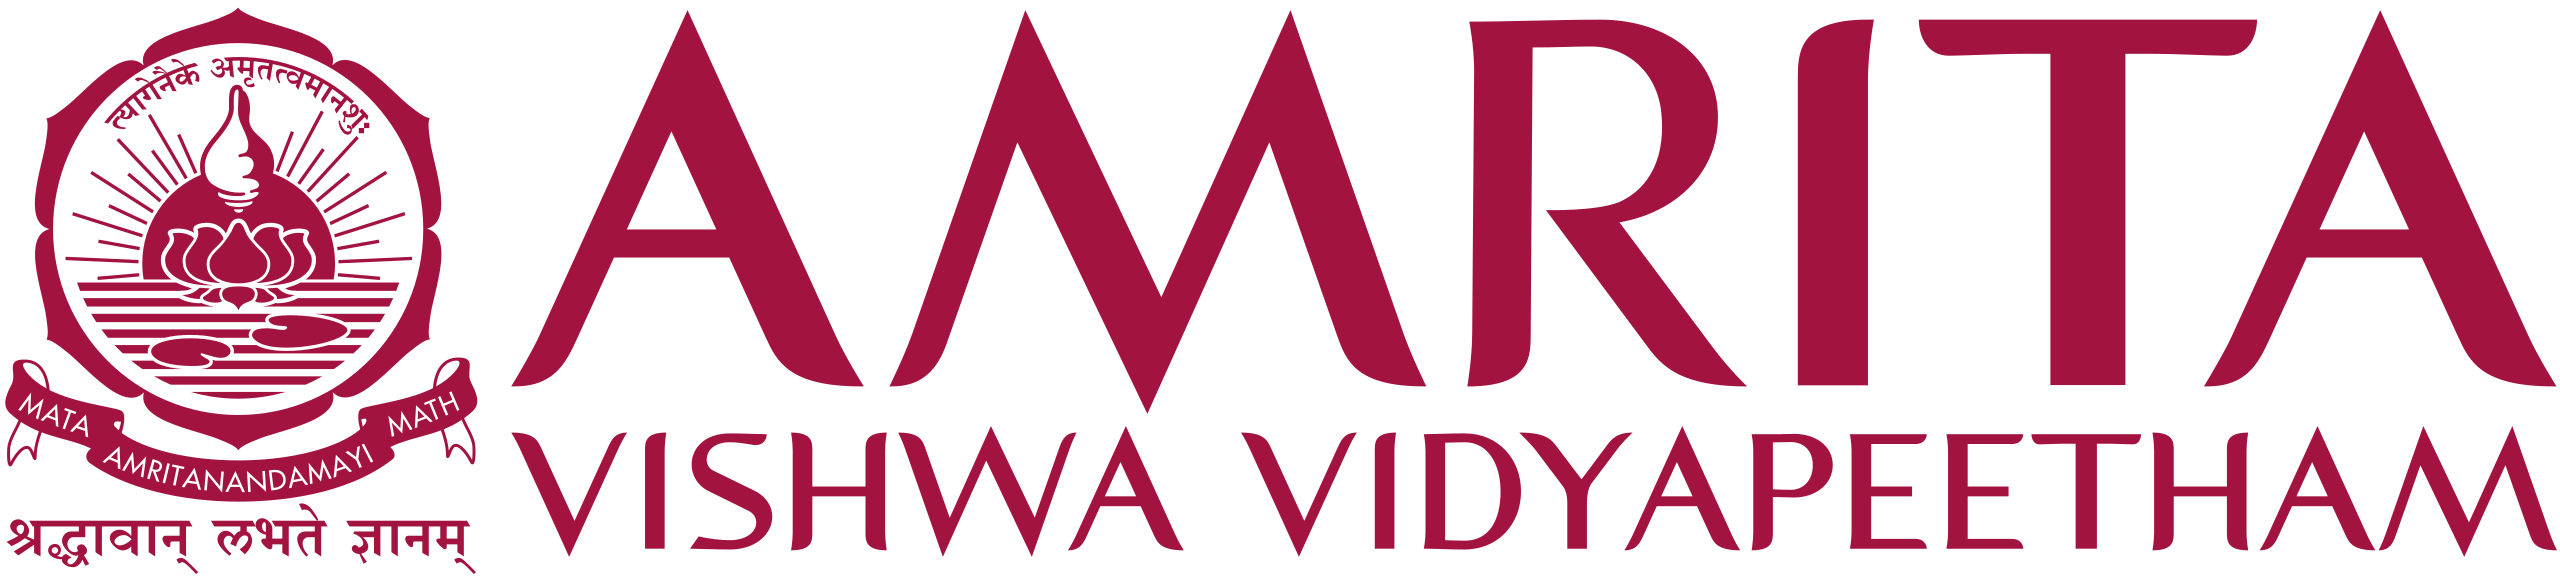

<center><h2 style="color:#b34700;">FOREGROUND AND BACKGROUND EXTRACTION</h2></center>

<center><h4>22MAT220 - Mathematics for Computing 3</h4></center>

<br><br>

<h3 style="text-align:right;">DONE BY</h3>

<p style="text-align:right;">
ROHITH RAVI CB.SC.U4AI.E24350 <br>
AKHILAN CB.SC.U4AI.E24362 <br>
APARNA CB.SC.U4AI.E24304 <br>
POORNIMA CB.SC.U4AI.E24343
</p>
</center>

## Robust PCA via ADMM

We aim to decompose a matrix \( M \) into:



$$M = L + S$$



$ ( L ):$ Low-rank background matrix  

$ ( S ):$ Sparse foreground matrix 

### Optimization Objective


$$
\min_{L, S} \|L\|_* + \lambda \|S\|_1 \quad \text{subject to} \quad M - L - S = 0
$$


### Agumented Lagrangian

      Let 
$$ R = L + S - M ,$$
 $( Y )$ be the dual variable. The augmented Lagrangian is:



$$
{L}(L, S, Y) = \|L\|_* + \lambda |S|_1 + \langle Y, L + S - M \rangle + \frac{\mu}{2} |L + S - M|_F^2
$$



$$
= |L|_* + \lambda |S|_1 + \langle Y, R \rangle + \frac{\mu}{2} |R|_F^2
$$




**Update Equation for L**

Let
$$
Q = M - S^{(k)} + \frac{1}{\mu} Y^{(k)}
$$
Then,
$$
L^{(k+1)} = \arg\min_{L} \|L\|_* + \frac{\mu}{2}\|L - Q\|_F^2
$$

Let
$$
Q = U\Sigma V^T
$$
be the SVD of $Q$. Then,
$$
L^{(k+1)} = U\,\mathrm{diag}\!\left(\max\!\left(\sigma_i - \frac{1}{\mu},\,0\right)\right)V^T
$$

This is the **Singular Value Thresholding (SVT)** operator:
$$
L^{(k+1)} = \mathrm{SVT}_{1/\mu}(Q)
$$

**Update Equation for S**

Let
$$
A = M - L^{(k+1)} + \frac{1}{\mu}Y^{(k)}
$$
Then:
$$
S^{(k+1)} = \arg\min_{S} \lambda\|S\|_1 + \frac{\mu}{2}\|S - A\|_F^2
$$

This is solved via **element-wise soft-thresholding**:
$$
S^{(k+1)} = \mathrm{Soft}_{\lambda/\mu}(A)
$$

Where:
$$
\mathrm{Soft}_{\tau}(x) = \begin{cases}
x - \tau, & x > \tau \\
x + \tau, & x < -\tau \\
0, & \mathrm{otherwise}
\end{cases}
$$

**Update Dual Variable y**



$$
Y^{(k+1)} = Y^{(k)} + \mu (M - L^{(k+1)} - S^{(k+1)})
$$



**The modules that are to be considered:**


In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [2]:
def separate_foreground_background(M, lambda_val=None, max_iter=500, tol=1e-7):
    m, n = M.shape
    L = np.zeros((m, n))
    S = np.zeros((m, n))
    Y = np.zeros((m, n))

    if lambda_val is None:
        lambda_val = 1.0 / np.sqrt(max(m, n))

    mu = 1.25 / np.linalg.norm(M, 2) # As suggested in literature
    mu_max = mu * 1e7
    rho = 1.5 # Multiplier for mu

    for i in range(max_iter):
        U, s, Vt = np.linalg.svd(M - S + Y / mu, full_matrices=False)
        s_thresh = np.maximum(s - 1/mu, 0) # Soft-thresholding on singular values
        L = U @ np.diag(s_thresh) @ Vt

        S_unthresh = M - L + Y / mu
        S = np.sign(S_unthresh) * np.maximum(np.abs(S_unthresh) - lambda_val / mu, 0)

        Y = Y + mu * (M - L - S)

        mu = min(mu * rho, mu_max)

        error = np.linalg.norm(M - L - S, 'fro') / np.linalg.norm(M, 'fro')
        print(f"Iteration {i}: Reconstruction Error = {error:.6f}")

        if error < tol:
            break

    print("\nADMM finished.")
    return L, S


Loading the image using the CV2 , and calling it with the ADMM function

Iteration 0: Reconstruction Error = 0.809390
Iteration 1: Reconstruction Error = 0.204901
Iteration 2: Reconstruction Error = 0.204901
Iteration 3: Reconstruction Error = 0.162720
Iteration 4: Reconstruction Error = 0.116214
Iteration 5: Reconstruction Error = 0.092895
Iteration 6: Reconstruction Error = 0.071157
Iteration 7: Reconstruction Error = 0.055722
Iteration 8: Reconstruction Error = 0.037115
Iteration 9: Reconstruction Error = 0.022323
Iteration 10: Reconstruction Error = 0.014576
Iteration 11: Reconstruction Error = 0.010160
Iteration 12: Reconstruction Error = 0.007076
Iteration 13: Reconstruction Error = 0.004911
Iteration 14: Reconstruction Error = 0.003391
Iteration 15: Reconstruction Error = 0.002349
Iteration 16: Reconstruction Error = 0.001616
Iteration 17: Reconstruction Error = 0.001114
Iteration 18: Reconstruction Error = 0.000764
Iteration 19: Reconstruction Error = 0.000515
Iteration 20: Reconstruction Error = 0.000344
Iteration 21: Reconstruction Error = 0.00023

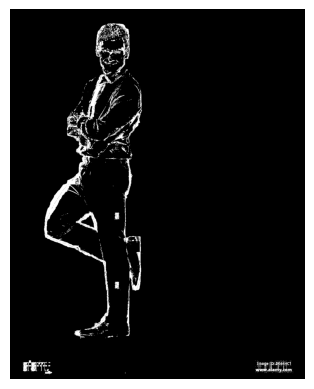

In [3]:
def cv2_imshow(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
image = cv2.imread("D:\Sem 3\MFC sem 3\Project Files\simple_image.jpg")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
normalized_image = gray_image.astype(np.float32) / 255.0
background_L, foreground_S = separate_foreground_background(normalized_image)
background_img = (np.clip(background_L, 0, 1) * 255).astype(np.uint8)
foreground_img = (np.clip(np.abs(foreground_S), 0, 1) * 255).astype(np.uint8)
_, foreground_thresh = cv2.threshold(foreground_img, 10, 255, cv2.THRESH_BINARY)
cv2_imshow(foreground_thresh)